# Notebook 04 — Hough Transform & Geometric Filtering

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 4:** Edge map → Probabilistic Hough → geometric filtering → segment merging

**Input:**
- Edge maps from `outputs/03_canny/`
- Calibration data from `outputs/02_rectified/calibration.json`

**Output:** Detected cut-edge lines saved to `outputs/04_hough/lines.json`

**Expected output:** 4 cut edges per image (2 rubber band pairs × 2 cut edges each)

**Strategy:**
1. Run Probabilistic Hough Transform on the clean edge map from NB03
2. Filter segments by orientation (near-vertical — cut edges are vertical lines)
3. Filter by spatial position (inside table area defined by QR corners)
4. Merge collinear nearby segments into one representative line per cut edge

## 1. Imports and configuration

In [12]:
!pip install opencv-python numpy matplotlib

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [14]:
# ── Paths ──────────────────────────────────────────────────────────────────
CANNY_DIR     = Path("outputs/03_canny")         # input from NB03
CALIB_PATH    = Path("outputs/02_rectified/calibration.json")  # from NB02
OUTPUT_DIR    = Path("outputs/04_hough")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Probabilistic Hough parameters ────────────────────────────────────────
HOUGH_RHO        = 1
HOUGH_THETA      = np.pi / 180
HOUGH_THRESHOLD  = 50
HOUGH_MIN_LEN    = 80     # min segment length (px)
HOUGH_MAX_GAP    = 30     # max gap between collinear segments (px)

# ── Geometric filter parameters ────────────────────────────────────────────
MAX_ANGLE_FROM_VERTICAL = 25   # degrees
SPATIAL_MARGIN_X        = 40   # px inward from QR x bounds
SPATIAL_MARGIN_Y        = 20   # px inward from QR y bounds

# ── Merging parameters ─────────────────────────────────────────────────────
MERGE_DIST_THR = 80   # px — segments within this x-distance are merged

# ── Expected detections ────────────────────────────────────────────────────
EXPECTED_EDGES = 4    # 2 rubber band pairs × 2 cut edges each

# Load calibration from NB02
with open(CALIB_PATH) as f:
    calibration_data = json.load(f)

print(f"Canny dir        : {CANNY_DIR.resolve()}")
print(f"Output dir       : {OUTPUT_DIR.resolve()}")
print(f"Calibrated images: {len(calibration_data)}")

Canny dir        : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\03_canny
Output dir       : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\04_hough
Calibrated images: 20


## 2. Probabilistic Hough Transform

In [15]:
def run_hough(edges: np.ndarray) -> np.ndarray | None:
    """Run Probabilistic Hough Transform. Returns (N,1,4) array or None."""
    return cv2.HoughLinesP(
        edges,
        rho           = HOUGH_RHO,
        theta         = HOUGH_THETA,
        threshold     = HOUGH_THRESHOLD,
        minLineLength = HOUGH_MIN_LEN,
        maxLineGap    = HOUGH_MAX_GAP
    )

## 3. Geometric filtering

Keep only segments that are near-vertical and inside the table area
defined by the QR exterior corners from NB02.

In [16]:
def angle_from_vertical(x1, y1, x2, y2) -> float:
    """Angle in degrees between segment and vertical axis."""
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    return 90.0 if dy == 0 else float(np.degrees(np.arctan2(dx, dy)))


def filter_segments(segments, calib: dict, img_shape: tuple) -> list:
    """
    Filter Hough segments by orientation and spatial position.
    Uses QR corners from calibration_data (saved by NB02).
    """
    if segments is None:
        return []

    H, W     = img_shape
    corners  = np.array(calib['corners_px'], dtype=float)
    x_min    = int(corners[:, 0].min()) + SPATIAL_MARGIN_X
    x_max    = int(corners[:, 0].max()) - SPATIAL_MARGIN_X
    y_min    = int(corners[:, 1].min()) + SPATIAL_MARGIN_Y
    y_max    = int(corners[:, 1].max()) - SPATIAL_MARGIN_Y

    filtered = []
    for seg in segments:
        x1, y1, x2, y2 = seg[0]
        if angle_from_vertical(x1, y1, x2, y2) > MAX_ANGLE_FROM_VERTICAL:
            continue
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        if not (x_min <= mx <= x_max and y_min <= my <= y_max):
            continue
        filtered.append([int(x1), int(y1), int(x2), int(y2)])

    return filtered

## 4. Segment merging

Group segments that are within MERGE_DIST_THR pixels in x and merge them
into one representative vertical line per cut edge.

In [17]:
def merge_segments(filtered: list, dist_thr: int = MERGE_DIST_THR) -> list:
    """
    Merge collinear segments within dist_thr pixels in x.
    Returns list of [x, y_top, x, y_bot] — one per detected cut edge.
    """
    if not filtered:
        return []

    segs          = sorted(filtered, key=lambda s: (s[0] + s[2]) / 2)
    groups        = []
    current_group = [segs[0]]

    for seg in segs[1:]:
        mx_new  = (seg[0] + seg[2]) / 2
        mx_last = np.mean([(s[0] + s[2]) / 2 for s in current_group])
        if abs(mx_new - mx_last) <= dist_thr:
            current_group.append(seg)
        else:
            groups.append(current_group)
            current_group = [seg]
    groups.append(current_group)

    merged = []
    for group in groups:
        xs     = [(s[0] + s[2]) / 2 for s in group]
        ys     = [s[1] for s in group] + [s[3] for s in group]
        x_mean = int(np.mean(xs))
        y_top  = int(min(ys))
        y_bot  = int(max(ys))
        merged.append([x_mean, y_top, x_mean, y_bot])

    return merged

## 5. Full pipeline per image

In [18]:
def process_image(image_name: str) -> dict | None:
    # Load edge map from NB03
    edges = cv2.imread(str(CANNY_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    if edges is None:
        print(f"  [SKIP] {image_name}")
        return None

    calib    = calibration_data[image_name]
    H, W     = edges.shape
    segments = run_hough(edges)
    filtered = filter_segments(segments, calib, (H, W))
    merged   = merge_segments(filtered)

    return {
        'image_name'    : image_name,
        'n_raw'         : len(segments) if segments is not None else 0,
        'n_filtered'    : len(filtered),
        'n_merged'      : len(merged),
        'cut_edges_px'  : merged
    }

In [19]:
hough_results = {}

for image_name in calibration_data:
    result = process_image(image_name)
    if result is not None:
        hough_results[image_name] = result
        flag = "✓" if result['n_merged'] == EXPECTED_EDGES else "✗"
        print(f"  [{flag}] {image_name:30s}  "
              f"raw={result['n_raw']:4d}  "
              f"filtered={result['n_filtered']:3d}  "
              f"merged={result['n_merged']:2d}")

correct = sum(1 for r in hough_results.values() if r['n_merged'] == EXPECTED_EDGES)
print(f"\nCorrect (n={EXPECTED_EDGES}): {correct} / {len(hough_results)} images")

# Save for NB05 and NB06
with open(OUTPUT_DIR / "lines.json", "w") as f:
    json.dump(hough_results, f, indent=2)
print(f"Saved to {OUTPUT_DIR / 'lines.json'}")

  [✗] Multimedia_31.jpg               raw=  51  filtered= 14  merged= 2
  [✗] Multimedia_32.jpg               raw=  77  filtered= 14  merged= 2
  [✗] Multimedia_33.jpg               raw=  57  filtered= 15  merged= 2
  [✗] Multimedia_34.jpg               raw=  57  filtered= 17  merged= 2
  [✓] Multimedia_35.jpg               raw=  79  filtered= 50  merged= 4
  [✓] Multimedia_36.jpg               raw=  79  filtered= 46  merged= 4
  [✓] Multimedia_37.jpg               raw=  88  filtered= 43  merged= 4
  [✗] Multimedia_39.jpg               raw=  73  filtered= 22  merged= 1
  [✗] Multimedia_40.jpg               raw=  75  filtered= 17  merged= 1
  [✗] Multimedia_41.jpg               raw=  68  filtered= 15  merged= 1
  [✗] Multimedia_42.jpg               raw=  64  filtered=  0  merged= 0
  [✗] Multimedia_43.jpg               raw=  57  filtered=  0  merged= 0
  [✓] Multimedia_45.jpg               raw=  62  filtered= 44  merged= 4
  [✓] Multimedia_46.jpg               raw=  51  filtered= 40  me

## 6. Visual inspection

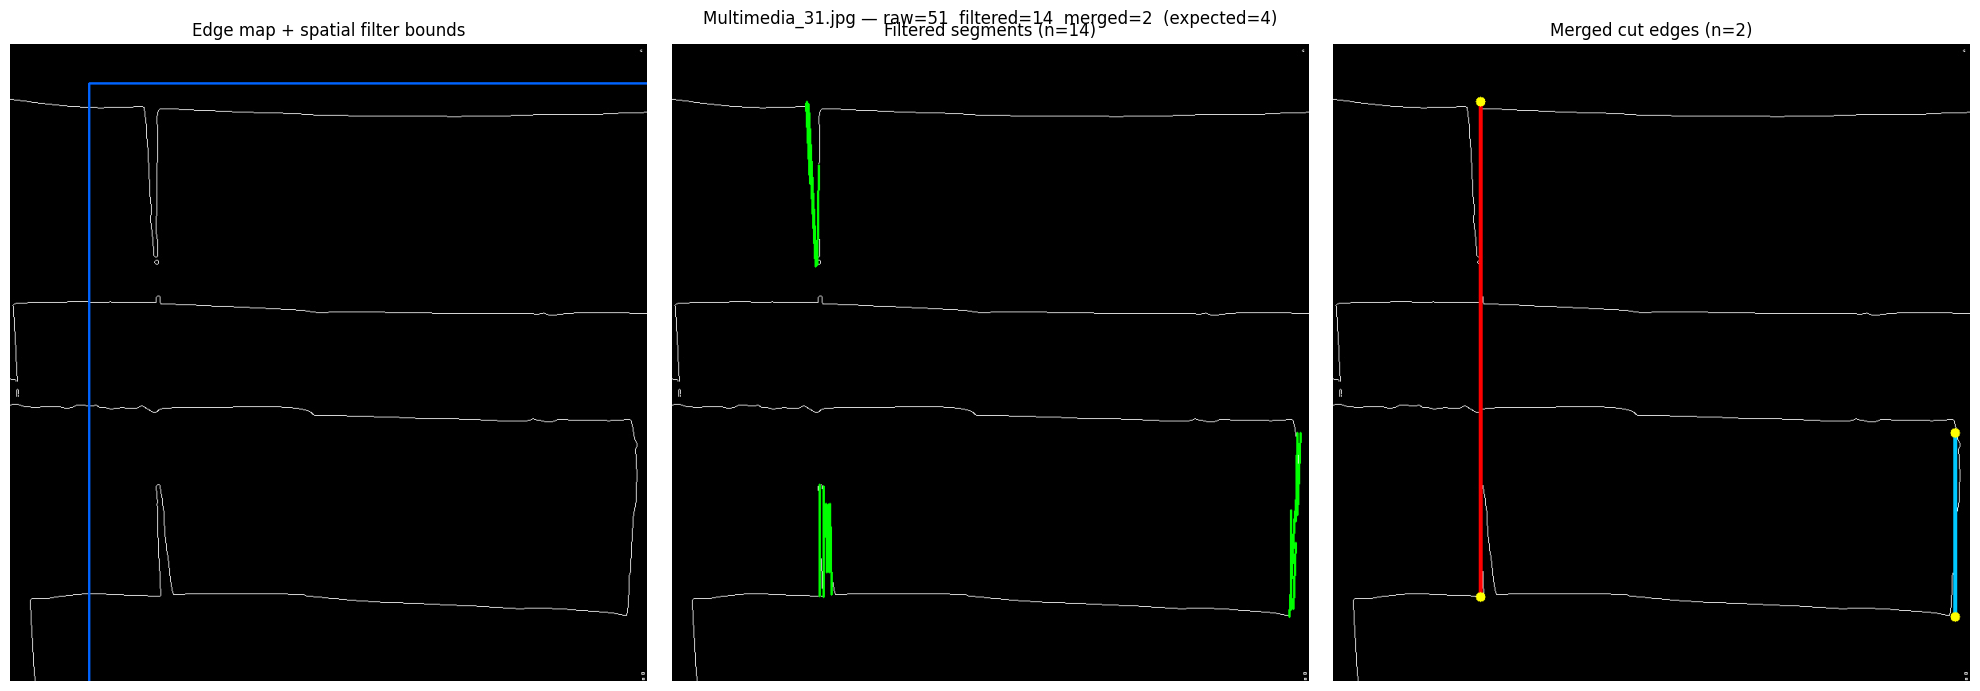

In [20]:
def visualize_result(image_name: str):
    result   = hough_results[image_name]
    calib    = calibration_data[image_name]
    edges    = cv2.imread(str(CANNY_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    H, W     = edges.shape

    segments = run_hough(edges)
    filtered = filter_segments(segments, calib, (H, W))
    merged   = result['cut_edges_px']

    corners  = np.array(calib['corners_px'], dtype=float)
    x_min    = int(corners[:, 0].min()) + SPATIAL_MARGIN_X
    x_max    = int(corners[:, 0].max()) - SPATIAL_MARGIN_X
    y_min    = int(corners[:, 1].min()) + SPATIAL_MARGIN_Y
    y_max    = int(corners[:, 1].max()) - SPATIAL_MARGIN_Y

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle(f"{image_name} — raw={result['n_raw']}  "
                 f"filtered={result['n_filtered']}  "
                 f"merged={result['n_merged']}  "
                 f"(expected={EXPECTED_EDGES})", fontsize=12)

    # Edge map with spatial bounds
    edge_vis = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(edge_vis, (x_min, y_min), (x_max, y_max), (0, 100, 255), 2)
    axes[0].imshow(edge_vis)
    axes[0].set_title('Edge map + spatial filter bounds')
    axes[0].axis('off')

    # Filtered segments
    filt_vis = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    for x1, y1, x2, y2 in filtered:
        cv2.line(filt_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    axes[1].imshow(filt_vis)
    axes[1].set_title(f'Filtered segments (n={len(filtered)})')
    axes[1].axis('off')

    # Merged cut edges
    merge_vis = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    colors = [(255,0,0), (0,200,255), (255,165,0), (0,255,0)]
    for i, (x1, y1, x2, y2) in enumerate(merged):
        color = colors[i % len(colors)]
        cv2.line(merge_vis, (x1, y1), (x2, y2), color, 3)
        cv2.circle(merge_vis, (x1, y1), 6, (255,255,0), -1)
        cv2.circle(merge_vis, (x2, y2), 6, (255,255,0), -1)
    axes[2].imshow(merge_vis)
    axes[2].set_title(f'Merged cut edges (n={len(merged)})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'check_{image_name}', dpi=120)
    plt.show()


visualize_result(next(iter(hough_results)))

In [21]:
# Visualize a specific image
# visualize_result("Multimedia_42.jpg")

## 7. Detection summary across all images

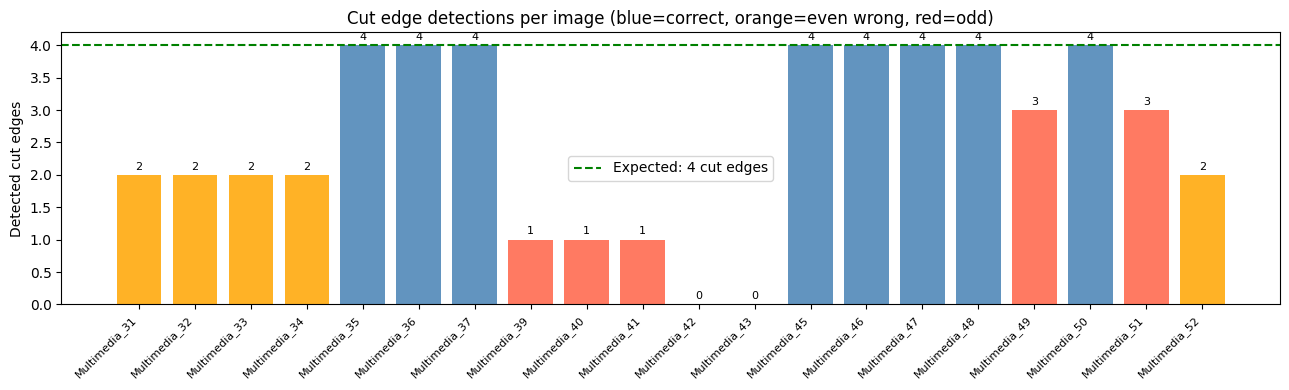

Correct (n=4)    : 8 / 20
Even wrong count : 7 / 20
Odd count (bad)  : 5 / 20


In [22]:
names   = list(hough_results.keys())
n_edges = [hough_results[n]['n_merged'] for n in names]

fig, ax = plt.subplots(figsize=(13, 4))
bar_colors = ['steelblue' if n == EXPECTED_EDGES else
              'tomato'    if n % 2 != 0 else
              'orange'    for n in n_edges]
ax.bar(range(len(names)), n_edges, color=bar_colors, alpha=0.85)
for i, n in enumerate(n_edges):
    ax.text(i, n + 0.05, str(n), ha='center', va='bottom', fontsize=8)
ax.axhline(EXPECTED_EDGES, color='green', linestyle='--',
           label=f'Expected: {EXPECTED_EDGES} cut edges')
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace('.jpg','') for n in names],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Detected cut edges')
ax.set_title('Cut edge detections per image '
             '(blue=correct, orange=even wrong, red=odd)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'detection_summary.png', dpi=150)
plt.show()

correct = sum(1 for n in n_edges if n == EXPECTED_EDGES)
even    = sum(1 for n in n_edges if n != EXPECTED_EDGES and n % 2 == 0)
odd     = sum(1 for n in n_edges if n % 2 != 0)
print(f"Correct (n={EXPECTED_EDGES})    : {correct} / {len(names)}")
print(f"Even wrong count : {even} / {len(names)}")
print(f"Odd count (bad)  : {odd} / {len(names)}")

## 8. Summary

| Step | Operation | Parameters |
|------|-----------|------------|
| 4a | Probabilistic Hough | threshold=50, minLen=80px, maxGap=30px |
| 4b | Orientation filter | max angle from vertical = 25° |
| 4c | Spatial filter | inward margin x=40px, y=20px from QR bounds |
| 4d | Segment merging | x-distance threshold = 80px |

**Output folder:** `outputs/04_hough/`  
**Lines file:** `outputs/04_hough/lines.json`  
**Used by:** NB05, NB06  
**Next notebook:** `05_metric.ipynb` — reads `lines.json` + `calibration.json`